Statistical methods and hypothesis testing

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, chi2_contingency, ttest_rel


In [2]:
np.random.seed(42)

In [3]:
# Three departments, salary data
hr_salaries =      [3200, 3400, 3100, 3300, 3250, 3150, 3400, 3300, 3280, 3350]
tech_salaries =    [3800, 4200, 3900, 4100, 3850, 4300, 3950, 4150, 4000, 4250]
finance_salaries = [3500, 3700, 3600, 3550, 3650, 3750, 3580, 3620, 3700, 3680]

# Training scores before and after a program
before_training = [65, 70, 68, 72, 66, 74, 69, 71, 67, 73]
after_training =  [70, 75, 74, 78, 72, 79, 75, 76, 73, 78]

# Department vs promotion (categorical)
dept_data = pd.DataFrame({
    'department': ['HR']*15 + ['Tech']*15 + ['Finance']*15,
    'promoted':   [1,0,0,1,0,1,0,0,1,0,1,0,0,1,0] +
                  [1,1,0,1,1,1,0,1,1,0,1,1,0,1,1] +
                  [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1]
})

dept_data

,department,promoted
0,HR,1
1,HR,0
2,HR,0
3,HR,1
4,HR,0
5,HR,1
6,HR,0
7,HR,0
8,HR,1
9,HR,0


In [16]:
#H0: The training produces the same score outcome as no training
#H1: The training produces a better score outcome as no training

t_stat, p_val= ttest_rel(after_training, before_training)

print(f'p_value: {p_val}')
print(f't_statistic: {t_stat}')

if p_val<0.05:
    print('The training actually worked')
else:
    print('Not enough evidence to suggest the training worked')

p_value: 1.0607712425468902e-10
t_statistic: 32.99999999999999
The training actually worked


In [23]:
#H0 There is no significant difference between salaries in different departments
#H1 There is significant difference between salaries in different departments

f_stat, p_val= f_oneway(hr_salaries, tech_salaries, finance_salaries)

print(f'F_statistic: {f_stat:.4f}')
print(f'p_value: {p_val:.10f}')

if p_val<0.05:
    print("There's great difference between the salaries in the different departments")
else:
    print("There's no significant difference between the salaries in the different departments")

F_statistic: 97.3363
p_value: 0.0000000000
There's great difference between the salaries in the different departments


In [ ]:
#ANOVA only shows the difference in variance between categories. It does not show which category actually has the highest variance. Saying tech earns higher is false since ANOVA only proves theres a big variance difference. I would tell my employee to follow the ANOVA test with a turkey test, to compare the departments two at a time

promoted    0   1
department       
Finance     7   8
HR          9   6
Tech        4  11
p_Value: 0.1809
Promotion IS INDEPENDENT of department


Text(0.5, 0, 'department')

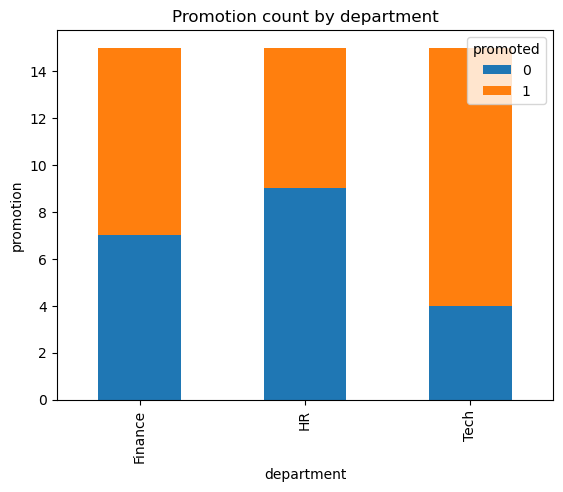

In [28]:
#H0 Promotion is independent of department
#H1 Promotion is dependent of department


contingency_table= pd.crosstab(dept_data['department'], dept_data['promoted'])
print(contingency_table)

chi2, p_val, dof, expected= chi2_contingency(contingency_table)

print(f'p_Value: {p_val:.4f}')

if p_val<0.05:
    print('Promotion IS DEPENDENT on department')
else:
    print('Promotion IS INDEPENDENT of department')

contingency_table.plot(kind= 'bar', stacked= True)
plt.title('Promotion count by department')
plt.ylabel('promotion')
plt.xlabel('department')
